# Unsupervised Fraud Detection using Isolation Forest

## Objective

Use an unsupervised anomaly detection approach to identify potentially suspicious financial transactions without relying directly on the fraud labels during model training.

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Base.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1000000, 32)


In [3]:
# Select numerical features for unsupervised anomaly detection

categorical_features = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]

constant_features = ["device_fraud_count"]

target_column = "fraud_bool"

numeric_features = [
    col for col in df.columns
    if col not in categorical_features + constant_features + [target_column]
]

X = df[numeric_features].copy()

print("Number of numerical features:", len(numeric_features))
print("Feature matrix shape:", X.shape)
print("\nFeatures used:")
print(numeric_features)

Number of numerical features: 25
Feature matrix shape: (1000000, 25)

Features used:
['income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'credit_risk_score', 'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'session_length_in_minutes', 'keep_alive_session', 'device_distinct_emails_8w', 'month']


In [4]:
# Check for missing values in the feature matrix

missing_values = X.isna().sum().sum()

print("Missing values in feature matrix:", missing_values)

Missing values in feature matrix: 0


In [5]:
# Train Isolation Forest on a representative sample

X_sample = X.sample(
    n=100000,
    random_state=42
)

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.011,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_sample)

print("Isolation Forest trained successfully.")
print("Training samples:", len(X_sample))
print("Number of trees:", isolation_forest.n_estimators)

Isolation Forest trained successfully.
Training samples: 100000
Number of trees: 200


In [6]:
# Generate anomaly predictions for all transactions

anomaly_predictions = isolation_forest.predict(X)

# Isolation Forest:
#  1  = normal
# -1  = anomaly
anomaly_count = (anomaly_predictions == -1).sum()
normal_count = (anomaly_predictions == 1).sum()

print("Anomaly detection completed.")
print("Normal transactions:", normal_count)
print("Anomalous transactions:", anomaly_count)

Anomaly detection completed.
Normal transactions: 988871
Anomalous transactions: 11129


In [7]:
# Evaluate Isolation Forest anomalies against the actual fraud labels

actual_fraud = df["fraud_bool"].values

anomaly_mask = anomaly_predictions == -1

actual_fraud_count = actual_fraud.sum()
fraud_detected = ((actual_fraud == 1) & anomaly_mask).sum()
false_alarms = ((actual_fraud == 0) & anomaly_mask).sum()

print("Actual fraud transactions:", actual_fraud_count)
print("Fraud transactions detected as anomalies:", fraud_detected)
print("False alarms:", false_alarms)
print("Fraud detection rate among actual fraud:", 
      round(fraud_detected / actual_fraud_count * 100, 2), "%")

Actual fraud transactions: 11029
Fraud transactions detected as anomalies: 269
False alarms: 10860
Fraud detection rate among actual fraud: 2.44 %


In [8]:
# Create an evaluation summary for the Isolation Forest model

isolation_forest_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Actual Fraud Transactions",
        "Detected Anomalies",
        "Fraud Detected as Anomalies",
        "False Alarms",
        "Fraud Detection Rate"
    ],
    "Value": [
        len(df),
        actual_fraud_count,
        anomaly_count,
        fraud_detected,
        false_alarms,
        round(fraud_detected / actual_fraud_count * 100, 2)
    ]
})

display(isolation_forest_summary)

,Metric,Value
0,Total Transactions,1000000.00
1,Actual Fraud Transactions,11029.00
2,Detected Anomalies,11129.00
3,Fraud Detected as Anomalies,269.00
4,False Alarms,10860.00
5,Fraud Detection Rate,2.44


In [9]:
# One-Class SVM setup

import pandas as pd
import numpy as np
import joblib

from pathlib import Path
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Base.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (1000000, 32)


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_ocsvm)

print("Feature scaling completed successfully.")
print("Scaled feature matrix shape:", X_scaled.shape)

NameError: name 'X_ocsvm' is not defined

## One-Class SVM

### Objective

Apply One-Class Support Vector Machine (One-Class SVM) as a second unsupervised anomaly detection approach and compare its behavior with Isolation Forest.

The model is trained without using `fraud_bool` as an input feature. The actual fraud labels are used only afterward for evaluation.

In [11]:
df = pd.read_csv("../data/raw/Base.csv")

print(df.shape)
df.head()
print(df.columns.tolist())

(1000000, 32)
['fraud_bool', 'income', 'name_email_similarity', 'prev_address_months_count', 'current_address_months_count', 'customer_age', 'days_since_request', 'intended_balcon_amount', 'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h', 'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w', 'employment_status', 'credit_risk_score', 'email_is_free', 'housing_status', 'phone_home_valid', 'phone_mobile_valid', 'bank_months_count', 'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source', 'session_length_in_minutes', 'device_os', 'keep_alive_session', 'device_distinct_emails_8w', 'device_fraud_count', 'month']


In [12]:
# Select features for One-Class SVM

ocsvm_features = [
    "income",
    "name_email_similarity",
    "prev_address_months_count",
    "current_address_months_count",
    "customer_age",
    "days_since_request",
    "intended_balcon_amount",
    "zip_count_4w",
    "velocity_6h",
    "velocity_24h",
    "velocity_4w",
    "bank_branch_count_8w",
    "date_of_birth_distinct_emails_4w",
    "credit_risk_score",
    "email_is_free",
    "phone_home_valid",
    "phone_mobile_valid",
    "bank_months_count",
    "has_other_cards",
    "proposed_credit_limit",
    "foreign_request",
    "session_length_in_minutes",
    "keep_alive_session",
    "device_distinct_emails_8w",
    "month"
]

missing_features = [
    col for col in ocsvm_features
    if col not in df.columns
]

print("Missing features:", missing_features)

X_ocsvm = df[ocsvm_features].copy()

X_ocsvm = X_ocsvm.replace(
    [np.inf, -np.inf],
    np.nan
)

X_ocsvm = X_ocsvm.fillna(
    X_ocsvm.median(numeric_only=True)
)

print("OCSVM feature matrix shape:", X_ocsvm.shape)

Missing features: []
OCSVM feature matrix shape: (1000000, 25)


In [13]:
# Standardize features for One-Class SVM

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_ocsvm)

print("Feature scaling completed successfully.")
print("Scaled feature matrix shape:", X_scaled.shape)

Feature scaling completed successfully.
Scaled feature matrix shape: (1000000, 25)


In [14]:
# Train One-Class SVM on a representative sample

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_scaled.shape[0],
    size=100000,
    replace=False
)

X_ocsvm_sample = X_scaled[sample_indices]

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.02
)

ocsvm.fit(X_ocsvm_sample)

print("One-Class SVM trained successfully.")
print("Training samples:", len(X_ocsvm_sample))

One-Class SVM trained successfully.
Training samples: 100000


In [15]:
# Generate One-Class SVM anomaly predictions

ocsvm_predictions = ocsvm.predict(X_scaled)

# 1 = normal
# -1 = anomaly

ocsvm_anomaly_mask = ocsvm_predictions == -1

print("Detected anomalies:", ocsvm_anomaly_mask.sum())
print(
    "Anomaly rate:",
    round(ocsvm_anomaly_mask.mean() * 100, 2),
    "%"
)

Detected anomalies: 21647
Anomaly rate: 2.16 %


In [16]:
# Evaluate One-Class SVM against actual fraud labels

actual_fraud = df["fraud_bool"].values

fraud_detected_ocsvm = (
    (actual_fraud == 1) &
    ocsvm_anomaly_mask
).sum()

false_alarms_ocsvm = (
    (actual_fraud == 0) &
    ocsvm_anomaly_mask
).sum()

actual_fraud_count = actual_fraud.sum()

print("Actual fraud transactions:", actual_fraud_count)
print("Fraud detected:", fraud_detected_ocsvm)
print("False alarms:", false_alarms_ocsvm)

print(
    "Fraud detection rate:",
    round(
        fraud_detected_ocsvm /
        actual_fraud_count * 100,
        2
    ),
    "%"
)

Actual fraud transactions: 11029
Fraud detected: 644
False alarms: 21003
Fraud detection rate: 5.84 %


In [17]:
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.02
)

ocsvm.fit(X_scaled)

print("One-Class SVM trained successfully.")

One-Class SVM trained successfully.


In [18]:
ocsvm_predictions = ocsvm.predict(X_scaled)

# One-Class SVM:
#  1  = normal
# -1  = anomaly

anomaly_predictions = (
    ocsvm_predictions == -1
).astype(int)

print("Detected anomalies:", anomaly_predictions.sum())
print("Anomaly rate:", round(anomaly_predictions.mean() * 100, 2), "%")

Detected anomalies: 19990
Anomaly rate: 2.0 %


In [19]:
missing_features = [
    col for col in ocsvm_features
    if col not in df.columns
]

print("Missing features:", missing_features)

Missing features: []


In [20]:
X_ocsvm = df[ocsvm_features].copy()

X_ocsvm = X_ocsvm.replace(
    [np.inf, -np.inf],
    np.nan
)

X_ocsvm = X_ocsvm.fillna(
    X_ocsvm.median(numeric_only=True)
)

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_ocsvm)

In [22]:
ocsvm_predictions = ocsvm.predict(X_scaled)

# One-Class SVM:
#  1  = normal
# -1  = anomaly

anomaly_predictions = (
    ocsvm_predictions == -1
).astype(int)

print(
    classification_report(
        df["fraud_bool"],
        anomaly_predictions,
        target_names=["Normal", "Fraud"]
    )
)

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98    988971
       Fraud       0.03      0.05      0.04     11029

    accuracy                           0.97   1000000
   macro avg       0.51      0.52      0.51   1000000
weighted avg       0.98      0.97      0.97   1000000



In [23]:
print(
    confusion_matrix(
        df["fraud_bool"],
        anomaly_predictions
    )
)

[[969579  19392]
 [ 10431    598]]


In [24]:
print(
    "Detected anomalies:",
    anomaly_predictions.sum()
)

print(
    "Anomaly rate:",
    anomaly_predictions.mean()
)

Detected anomalies: 19990
Anomaly rate: 0.01999


## Comparison of Unsupervised Models

Isolation Forest and One-Class SVM were both applied as unsupervised anomaly detection techniques.

The two models use different approaches:

- **Isolation Forest** isolates unusual observations using randomly constructed decision trees.
- **One-Class SVM** learns a boundary around the majority of observations and identifies observations outside that boundary as anomalies.

The actual fraud labels are used only for post-hoc evaluation and are not used during model training.

In [25]:
# Compare anomaly detection results from both unsupervised models

isolation_anomaly_mask = isolation_forest.predict(X) == -1
ocsvm_anomaly_mask = ocsvm.predict(X_scaled) == -1

actual_fraud = df["fraud_bool"].values

comparison_data = {
    "Model": [
        "Isolation Forest",
        "One-Class SVM"
    ],
    "Detected Anomalies": [
        int(isolation_anomaly_mask.sum()),
        int(ocsvm_anomaly_mask.sum())
    ],
    "Fraud Detected": [
        int(((actual_fraud == 1) & isolation_anomaly_mask).sum()),
        int(((actual_fraud == 1) & ocsvm_anomaly_mask).sum())
    ],
    "False Alarms": [
        int(((actual_fraud == 0) & isolation_anomaly_mask).sum()),
        int(((actual_fraud == 0) & ocsvm_anomaly_mask).sum())
    ]
}

unsupervised_comparison = pd.DataFrame(comparison_data)

unsupervised_comparison["Fraud Detection Rate (%)"] = (
    unsupervised_comparison["Fraud Detected"]
    / actual_fraud_count
    * 100
).round(2)

display(unsupervised_comparison)

,Model,Detected Anomalies,Fraud Detected,False Alarms,Fraud Detection Rate (%)
0,Isolation Forest,11129,269,10860,2.44
1,One-Class SVM,19990,598,19392,5.42


In [26]:
ocsvm_bundle = {
    "model": ocsvm,
    "scaler": scaler,
    "features": ocsvm_features
}

joblib.dump(
    ocsvm_bundle,
    "../ocsvm_model_bundle.joblib"
)

print("One-Class SVM model saved successfully.")

One-Class SVM model saved successfully.


# Graph-Based Fraud Analysis

## Objective

Use graph-based analysis to identify groups of transactions that share similar transaction characteristics and examine whether suspicious transactions form connected clusters.

Since the dataset does not contain explicit customer, account, or device identifiers, the graph is constructed as a transaction similarity network rather than a real-world customer relationship network.

In [27]:
import sys
print(sys.executable)
!{sys.executable} -m pip install networkx

C:\Users\prala\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [28]:
import networkx as nx
print("NetworkX version:", nx.__version__)

NetworkX version: 3.6.1


In [29]:
import networkx as nx
import matplotlib.pyplot as plt

print("Graph analysis libraries imported successfully.")

Graph analysis libraries imported successfully.


In [30]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Base.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Fraud transactions:", df["fraud_bool"].sum())
print("Normal transactions:", (df["fraud_bool"] == 0).sum())

Dataset loaded successfully.
Shape: (1000000, 32)
Fraud transactions: 11029
Normal transactions: 988971


In [31]:
fraud_df = df[df["fraud_bool"] == 1]
normal_df = df[df["fraud_bool"] == 0]

graph_fraud = fraud_df.sample(
    n=min(500, len(fraud_df)),
    random_state=42
)

graph_normal = normal_df.sample(
    n=500,
    random_state=42
)

graph_df = pd.concat(
    [graph_fraud, graph_normal],
    ignore_index=True
)

print("Graph dataset shape:", graph_df.shape)
print("Fraud transactions:", graph_df["fraud_bool"].sum())
print(
    "Normal transactions:",
    (graph_df["fraud_bool"] == 0).sum()
)

Graph dataset shape: (1000, 32)
Fraud transactions: 500
Normal transactions: 500


In [32]:
# Attributes used to determine transaction similarity

graph_features = [
    "payment_type",
    "employment_status",
    "housing_status",
    "source",
    "device_os"
]

print("Graph similarity features:")
print(graph_features)

Graph similarity features:
['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


In [33]:
# Build transaction similarity graph

G = nx.Graph()

# Add transaction nodes
for idx, row in graph_df.iterrows():
    G.add_node(
        idx,
        fraud=int(row["fraud_bool"])
    )

# Connect transactions sharing multiple attributes
for i in range(len(graph_df)):
    for j in range(i + 1, len(graph_df)):

        similarity = sum(
            graph_df.iloc[i][feature] ==
            graph_df.iloc[j][feature]
            for feature in graph_features
        )

        # Create an edge when at least 3 characteristics match
        if similarity >= 3:
            G.add_edge(
                i,
                j,
                similarity=similarity
            )

print("Graph created successfully.")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Graph created successfully.
Number of nodes: 1000
Number of edges: 236553


In [34]:
# Calculate basic graph statistics
import numpy as np

degrees = dict(G.degree())

print("Graph Statistics")
print("----------------")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print(
    "Average degree:",
    round(np.mean(list(degrees.values())), 2)
)
print(
    "Connected components:",
    nx.number_connected_components(G)
)

Graph Statistics
----------------
Nodes: 1000
Edges: 236553
Average degree: 473.11
Connected components: 1


In [35]:
# Identify highly connected transactions

degree_centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame({
    "transaction_index": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values())
})

centrality_df["fraud_bool"] = centrality_df[
    "transaction_index"
].map(
    graph_df["fraud_bool"]
)

centrality_df = centrality_df.sort_values(
    "degree_centrality",
    ascending=False
)

display(
    centrality_df.head(10)
)

,transaction_index,degree_centrality,fraud_bool
2,2,0.651652,1
343,343,0.651652,1
352,352,0.651652,1
37,37,0.651652,1
47,47,0.651652,1
905,905,0.651652,0
312,312,0.651652,1
363,363,0.651652,1
368,368,0.651652,1
372,372,0.651652,1


In [36]:
# Compare fraud concentration among highly connected transactions

top_n = min(100, len(centrality_df))

top_connected = centrality_df.head(top_n)

fraud_in_top_connected = (
    top_connected["fraud_bool"].sum()
)

overall_fraud_rate = (
    graph_df["fraud_bool"].mean()
)

top_connected_fraud_rate = (
    top_connected["fraud_bool"].mean()
)

print(
    "Overall graph fraud rate:",
    round(overall_fraud_rate * 100, 2),
    "%"
)

print(
    "Fraud rate among top connected transactions:",
    round(top_connected_fraud_rate * 100, 2),
    "%"
)

print(
    "Fraud transactions among top connected transactions:",
    int(fraud_in_top_connected)
)

Overall graph fraud rate: 50.0 %
Fraud rate among top connected transactions: 81.0 %
Fraud transactions among top connected transactions: 81


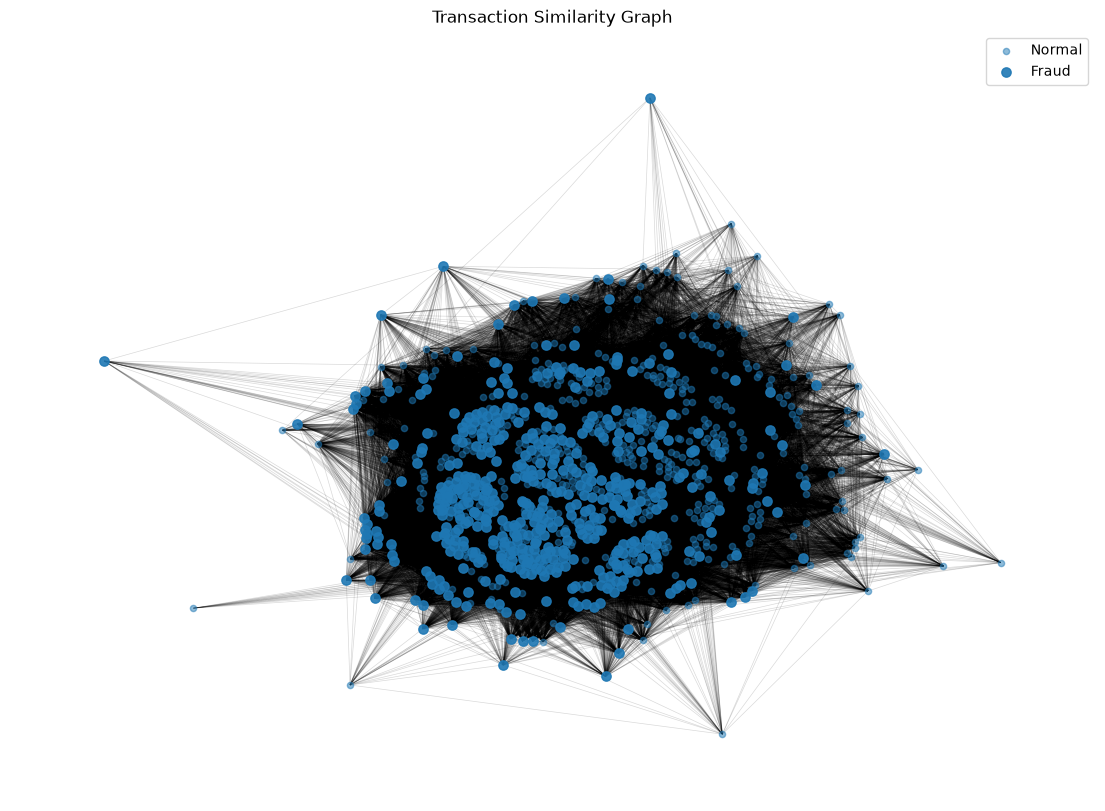

In [37]:
# Visualize the transaction similarity graph

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.5
)

normal_nodes = [
    node for node, data in G.nodes(data=True)
    if data["fraud"] == 0
]

fraud_nodes = [
    node for node, data in G.nodes(data=True)
    if data["fraud"] == 1
]

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15,
    width=0.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=normal_nodes,
    node_size=20,
    alpha=0.5,
    label="Normal"
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=fraud_nodes,
    node_size=45,
    alpha=0.9,
    label="Fraud"
)

plt.title(
    "Transaction Similarity Graph"
)

plt.legend()
plt.axis("off")
plt.show()

## Conclusion

Isolation Forest was implemented as an unsupervised anomaly detection approach for the financial fraud detection project.

The model identified 11,129 transactions as anomalous, including 269 actual fraud transactions. This resulted in a fraud detection rate of 2.44%.

The results show that unsupervised anomaly detection can provide an additional layer for identifying unusual transactions, but it should not replace the supervised fraud detection model. The HistGradientBoosting model remains the primary fraud detection model, while Isolation Forest can be used as a supporting anomaly detection layer.